# FDS Project

### Loading Libraries as specified in requirements.txt

In [211]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec  # Add this import
import seaborn as sns
import statsmodels.formula.api as smf
import csv 
import sklearn.preprocessing
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler



# PCA, K-Nearest Neighbours 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import sklearn
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_val_score
from sklearn.utils import resample

# Randomness,sampling simulations
from scipy.stats import uniform, norm, expon

# Bootstrap
import statsmodels.formula.api as smf # Regression library
from scipy.stats import norm # Object to with member functions to do with normal distributions

# logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.dates as mdates
from datetime import datetime

### Loading datasets and Cleaning

In [212]:
# Categories cleaning 
categories_loc = os.path.join(os.getcwd(), 'steam-insights', 'categories.csv')
categories = pd.read_csv(categories_loc)

categories['category'] = categories['category'].astype('string')
categories= categories.groupby('app_id')['category'].apply(list).reset_index()
categories.head()

,app_id,category
0,10,"[Family Sharing, Multi-player, Online PvP, PvP..."
1,20,"[Family Sharing, Multi-player, Online PvP, PvP..."
2,30,"[Family Sharing, Multi-player, Valve Anti-Chea..."
3,40,"[Family Sharing, Multi-player, Online PvP, PvP..."
4,50,"[Family Sharing, Multi-player, Remote Play Tog..."


In [213]:
# Reviews cleaning 

reviews_loc = os.path.join(os.getcwd(), 'steam-insights', 'reviews.csv')
reviews = pd.read_csv(reviews_loc, 
                     na_values=['\\N'],  # Treat \N as NULL
                     keep_default_na=True,
                     on_bad_lines='skip')

#print("Missing values in reviews DataFrame:", reviews.isna().sum())

# Drop columns with many na's
reviews = reviews.drop(columns=['metacritic_score', 'reviews', 'recommendations', 
                              'steamspy_score_rank', 'steamspy_positive', 
                              'steamspy_negative'], axis=1)

reviews = reviews.dropna(subset=['steamspy_user_score','review_score'])

reviews['app_id'] = reviews['app_id'].astype(int)
reviews['review_score'] = reviews['review_score'].astype(int)
reviews['review_score_description'] = reviews['review_score_description'].astype('string')
reviews['steamspy_user_score'] = pd.to_numeric(reviews['steamspy_user_score'], errors='coerce')
reviews = reviews.dropna(subset=['steamspy_user_score'])

reviews





C:\Users\Georg\AppData\Local\Temp\ipykernel_14856\635953098.py:4: DtypeWarning: Columns (0,1,8,9,10) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.read_csv(reviews_loc,


,app_id,review_score,review_score_description,positive,negative,total,steamspy_user_score
0,10,9,Overwhelmingly Positive,235403.0,6207.0,241610.0,0.0
1,20,8,Very Positive,7315.0,1094.0,8409.0,0.0
2,30,8,Very Positive,6249.0,672.0,6921.0,0.0
3,40,8,Very Positive,2542.0,524.0,3066.0,0.0
4,50,9,Overwhelmingly Positive,22263.0,1111.0,23374.0,0.0
...,...,...,...,...,...,...,...
140133,3297700,0,No user reviews,0.0,0.0,0.0,0.0
140134,3297890,0,1 user reviews,0.0,1.0,1.0,0.0
140135,3298020,0,No user reviews,0.0,0.0,0.0,0.0
140136,3298610,0,No user reviews,0.0,0.0,0.0,0.0


In [214]:
# steamspy cleaning 

steamspy_loc = os.path.join(os.getcwd(), 'steam-insights', 'steamspy_insights.csv')
steamspy = pd.read_csv(steamspy_loc, on_bad_lines='skip', na_values=[r'\N'])  # Ensure \N is treated as NA
steamspy = steamspy.dropna(subset=['developer','genres','publisher','languages'])
steamspy['developer'] = steamspy['developer'].astype('string')
steamspy['publisher'] = steamspy['publisher'].astype('string')
#steamspy['languages'] = steamspy['languages'].astype('string')
steamspy['genres'] = steamspy['genres'].astype('string')

# Extract and calculate average owners from the range
def extract_owners_average(owners_range):
    try:
        # Extract the numbers from the range (format like "10,000,000 .. 20,000,000")
        parts = owners_range.replace(',', '').split('..')
        min_owners = int(parts[0].strip())
        max_owners = int(parts[1].strip())
        return (min_owners + max_owners) / 2
    except (ValueError, AttributeError, IndexError):
        return None

# Apply the function to create a new column
steamspy['owners_average'] = steamspy['owners_range'].apply(extract_owners_average)

steamspy.head()


,app_id,developer,publisher,owners_range,concurrent_users_yesterday,playtime_average_forever,playtime_average_2weeks,playtime_median_forever,playtime_median_2weeks,price,initial_price,discount,languages,genres,owners_average
0,10,Valve,Valve,"10,000,000 .. 20,000,000",11457,0,0,0,0,999.0,999.0,0.0,"English, French, German, Italian, Spanish - Sp...",Action,15000000.0
1,20,Valve,Valve,"5,000,000 .. 10,000,000",52,0,0,0,0,499.0,499.0,0.0,"English, French, German, Italian, Spanish - Sp...",Action,7500000.0
2,30,Valve,Valve,"5,000,000 .. 10,000,000",82,0,0,0,0,499.0,499.0,0.0,"English, French, German, Italian, Spanish - Spain",Action,7500000.0
3,40,Valve,Valve,"5,000,000 .. 10,000,000",6,0,0,0,0,499.0,499.0,0.0,"English, French, German, Italian, Spanish - Sp...",Action,7500000.0
4,50,Gearbox Software,Valve,"2,000,000 .. 5,000,000",99,0,0,0,0,499.0,499.0,0.0,"English, French, German, Korean",Action,3500000.0


In [215]:
# Games cleaning 

games_loc = os.path.join(os.getcwd(), 'steam-insights', 'games.csv')
games = pd.read_csv(
    games_loc, 
    encoding='utf-8',
    escapechar='\\',  # Handle escape characters
    quotechar='"',    # Specify quote character
    on_bad_lines='skip'
)


games['release_date'] = pd.to_datetime(games['release_date'], format='%Y-%m-%d', errors='coerce')
games['name'] = games['name'].astype('string')
games['type'] = games['type'].astype('string')

# Convert to string to ensure we're working with strings
games['price_overview'] = games['price_overview'].astype(str)

# Extract final price
games['price_final'] = games['price_overview'].str.extract(r'"final":\s*(\d+)').astype(float) / 100

# Extract initial price
games['price_initial'] = games['price_overview'].str.extract(r'"initial":\s*(\d+)').astype(float) / 100

# Extract currency
games['currency'] = games['price_overview'].str.extract(r'"currency":\s*"([^"]+)')

games['currency'] = games['currency'].astype('string')



games = games.drop(columns=['price_overview', 'languages'])

paid_games = games[(games['type'] == 'game') & (games['is_free'] == 0)]
paid_games = paid_games.dropna(subset=['price_final','release_date'])

free_games = games[(games['type'] == 'game') & (games['is_free']==1)]
free_games = free_games.drop(columns=['price_final','price_initial','currency'])
free_games = free_games.dropna(subset=['release_date'])

demos = games[games['type'] != 'game']
demos = demos.drop(columns=['price_final','price_initial','currency'])
demos = demos.dropna(subset=['release_date'])


In [216]:
# genres cleaning
genres_loc = os.path.join(os.getcwd(), 'steam-insights', 'genres.csv')
genres = pd.read_csv(genres_loc)

genres['genre'] = genres['genre'].astype('string')

genres.head()


,app_id,genre
0,10,Action
1,20,Action
2,30,Action
3,40,Action
4,50,Action


In [217]:
# tags cleaning 
tags_loc = os.path.join(os.getcwd(), 'steam-insights', 'tags.csv')
tags = pd.read_csv(tags_loc)

tags['tag'] = tags['tag'].astype('string')
tags= tags.groupby('app_id')['tag'].apply(list).reset_index()

tags.head()

,app_id,tag
0,10,"[1980s, 1990's, Action, Assassin, Classic, Com..."
1,20,"[1990's, Action, Class-Based, Classic, Co-op, ..."
2,30,"[Action, Class-Based, Classic, Co-op, Difficul..."
3,40,"[1990's, Action, Arena Shooter, Classic, Co-op..."
4,50,"[1990's, Action, Adventure, Aliens, Atmospheri..."


### Filtered and merged paid games

In [218]:
# Paid games dataset 
filtered_paid_games = paid_games.copy()
filtered_paid_games = filtered_paid_games.merge(genres, on='app_id', how='inner')
filtered_paid_games = filtered_paid_games[(filtered_paid_games['genre'] != 'Audio Production') & 
                    (filtered_paid_games['genre'] != 'Accounting') &
                    (filtered_paid_games['genre'] != 'Utilities') & 
                    (filtered_paid_games['genre'] != 'Video Production') &
                    (filtered_paid_games['genre'] != 'Design & Illustration') & 
                    (filtered_paid_games['genre'] != 'Game Development') &
                    (filtered_paid_games['genre'] != 'Web Publishing') & 
                    (filtered_paid_games['genre'] != 'Software Training') &
                    (filtered_paid_games['genre'] != 'Animation & Modeling') & 
                    (filtered_paid_games['genre'] != 'Photo Editing') &
                    (filtered_paid_games['genre'] != 'Documentary') &
                    (filtered_paid_games['genre'] != 'Education') &
                    (filtered_paid_games['genre'] != 'Episodic') &
                    (filtered_paid_games['genre'] != 'Movie') &
                    (filtered_paid_games['genre'] != 'Short') &
                    (filtered_paid_games['genre'] != 'Tutorial') &
                    (filtered_paid_games['genre'] != '360 Video') &
                    (filtered_paid_games['genre'] != 'Free To Play')]
filtered_paid_games['release_year'] = filtered_paid_games['release_date'].dt.year

# Merge on Positive Reviews
filtered_paid_games = filtered_paid_games.merge(reviews[['app_id', 'review_score', 'review_score_description', 'positive', 'negative', 'total']], on='app_id', how='inner')
# Avoid duplication of Games
filtered_paid_games = filtered_paid_games.groupby(['app_id', 'name', 'release_date', 'is_free',
                                               'type', 'price_final', 'price_initial',
                                               'currency', 'release_year', 'positive', 
                                               'review_score', 'review_score_description', 
                                               'negative', 'total'])['genre'].agg(list).reset_index()
# Merge on concurrent players 
filtered_paid_games = filtered_paid_games.merge(steamspy[['app_id','concurrent_users_yesterday','owners_average']], on='app_id', how='inner')
# Merge on tags 
filtered_paid_games = filtered_paid_games.merge(tags[['app_id','tag']], on='app_id', how='inner')
# Merge on Categories 
filtered_paid_games = filtered_paid_games.merge(categories[['app_id','category']], on='app_id', how='inner')
# Extract year 
filtered_paid_games['release_year'] = filtered_paid_games['release_date'].dt.year
# Calculate the price difference from initial release to current 
filtered_paid_games['price_difference'] = filtered_paid_games['price_initial']-filtered_paid_games['price_final']

# Drop columns not needed 
filtered_paid_games.drop(columns=['is_free','type'], inplace=True)



copy_filtered_paid_games = filtered_paid_games.copy()

filtered_paid_games.head()

,app_id,name,release_date,price_final,price_initial,currency,release_year,positive,review_score,review_score_description,negative,total,genre,concurrent_users_yesterday,owners_average,tag,category,price_difference
0,10,Counter-Strike,2000-11-01,8.19,8.19,EUR,2000,235403.0,9,Overwhelmingly Positive,6207.0,241610.0,[Action],11457,15000000.0,"[1980s, 1990's, Action, Assassin, Classic, Com...","[Family Sharing, Multi-player, Online PvP, PvP...",0.0
1,20,Team Fortress Classic,1999-04-01,4.99,4.99,EUR,1999,7315.0,8,Very Positive,1094.0,8409.0,[Action],52,7500000.0,"[1990's, Action, Class-Based, Classic, Co-op, ...","[Family Sharing, Multi-player, Online PvP, PvP...",0.0
2,30,Day of Defeat,2003-05-01,4.99,4.99,EUR,2003,6249.0,8,Very Positive,672.0,6921.0,[Action],82,7500000.0,"[Action, Class-Based, Classic, Co-op, Difficul...","[Family Sharing, Multi-player, Valve Anti-Chea...",0.0
3,40,Deathmatch Classic,2001-06-01,4.99,4.99,EUR,2001,2542.0,8,Very Positive,524.0,3066.0,[Action],6,7500000.0,"[1990's, Action, Arena Shooter, Classic, Co-op...","[Family Sharing, Multi-player, Online PvP, PvP...",0.0
4,50,Half-Life: Opposing Force,1999-11-01,4.99,4.99,EUR,1999,22263.0,9,Overwhelmingly Positive,1111.0,23374.0,[Action],99,3500000.0,"[1990's, Action, Adventure, Aliens, Atmospheri...","[Family Sharing, Multi-player, Remote Play Tog...",0.0


### Filtered and merged free games

In [219]:
# Free games dataset 
filtered_free_games = free_games.copy()
filtered_free_games = filtered_free_games.merge(genres, on='app_id', how='inner')
filtered_free_games = filtered_free_games[(filtered_free_games['genre'] != 'Audio Production') & 
          (filtered_free_games['genre'] != 'Accounting') &
          (filtered_free_games['genre'] != 'Utilities') & 
          (filtered_free_games['genre'] != 'Video Production') &
          (filtered_free_games['genre'] != 'Design & Illustration') & 
          (filtered_free_games['genre'] != 'Game Development') &
          (filtered_free_games['genre'] != 'Web Publishing') & 
          (filtered_free_games['genre'] != 'Software Training') &
          (filtered_free_games['genre'] != 'Animation & Modeling') & 
          (filtered_free_games['genre'] != 'Photo Editing') &
          (filtered_free_games['genre'] != 'Documentary') &
          (filtered_free_games['genre'] != 'Education') &
          (filtered_free_games['genre'] != 'Episodic') &
          (filtered_free_games['genre'] != 'Movie') &
          (filtered_free_games['genre'] != 'Short') &
          (filtered_free_games['genre'] != 'Tutorial') &
          (filtered_free_games['genre'] != '360 Video') &
          (filtered_free_games['genre'] != 'Free To Play')]
filtered_free_games['release_year'] = filtered_free_games['release_date'].dt.year

# Merge on Positive Reviews
filtered_free_games = filtered_free_games.merge(reviews[['app_id', 'review_score', 'review_score_description', 'positive', 'negative', 'total']], on='app_id', how='inner')
# Avoid duplication of Games
filtered_free_games = filtered_free_games.groupby(['app_id', 'name', 'release_date', 'is_free',
                         'type', 'release_year', 'positive', 
                         'review_score', 'review_score_description', 
                         'negative', 'total'])['genre'].agg(list).reset_index()
# Merge on concurrent players 
filtered_free_games = filtered_free_games.merge(steamspy[['app_id','concurrent_users_yesterday','owners_average']], on='app_id', how='inner')
# Merge on tags 
filtered_free_games = filtered_free_games.merge(tags[['app_id','tag']], on='app_id', how='inner')
# Merge on Categories 
filtered_free_games = filtered_free_games.merge(categories[['app_id','category']], on='app_id', how='inner')
# Extract year 
filtered_free_games['release_year'] = filtered_free_games['release_date'].dt.year
# Drop columns not needed 
filtered_free_games.drop(columns=['is_free','type'], inplace=True)


filtered_free_games.head()

,app_id,name,release_date,release_year,positive,review_score,review_score_description,negative,total,genre,concurrent_users_yesterday,owners_average,tag,category
0,440,Team Fortress 2,2007-10-10,2007,990978.0,8,Very Positive,130730.0,1121708.0,[Action],59701,75000000.0,"[Action, Cartoon, Cartoony, Class-Based, Co-op...","[Captions available, Commentary available, Cro..."
1,630,Alien Swarm,2010-07-19,2010,20019.0,8,Very Positive,1089.0,21108.0,[Action],16,3500000.0,"[Action, Adventure, Aliens, Class-Based, Co-op...","[Captions available, Co-op, Includes level edi..."
2,3483,Peggle Extreme,2007-09-11,2007,2069.0,8,Very Positive,120.0,2189.0,[Casual],21,350000.0,"[2D, Action, Arcade, Casual, Classic, Free to ...","[Remote Play on Phone, Remote Play on Tablet, ..."
3,4900,Zen of Sudoku,2006-12-14,2006,280.0,8,Very Positive,33.0,313.0,"[Casual, Indie]",11,35000.0,"[Casual, Free to Play, Indie, Puzzle, Relaxing...",[Single-player]
4,6370,Bloodline Champions,2011-10-28,2011,1441.0,8,Very Positive,246.0,1687.0,"[Action, Massively Multiplayer]",3,750000.0,"[Action, Competitive, Fast-Paced, Free to Play...","[MMO, Multi-player, Single-player]"


# Testing Data 

In [220]:
# Drop price-related columns from the paid games dataset
paid_without_prices = filtered_paid_games.drop(
    columns=['price_final', 'price_initial', 'currency', 'price_difference']
)

# Combine the modified paid games dataset with the free games dataset
combined_games = pd.concat([paid_without_prices, filtered_free_games], axis=0)

temporal_analysis = combined_games.copy()

combined_games = combined_games[combined_games['review_score'] > 0]

combined_games.head()


,app_id,name,release_date,release_year,positive,review_score,review_score_description,negative,total,genre,concurrent_users_yesterday,owners_average,tag,category
0,10,Counter-Strike,2000-11-01,2000,235403.0,9,Overwhelmingly Positive,6207.0,241610.0,[Action],11457,15000000.0,"[1980s, 1990's, Action, Assassin, Classic, Com...","[Family Sharing, Multi-player, Online PvP, PvP..."
1,20,Team Fortress Classic,1999-04-01,1999,7315.0,8,Very Positive,1094.0,8409.0,[Action],52,7500000.0,"[1990's, Action, Class-Based, Classic, Co-op, ...","[Family Sharing, Multi-player, Online PvP, PvP..."
2,30,Day of Defeat,2003-05-01,2003,6249.0,8,Very Positive,672.0,6921.0,[Action],82,7500000.0,"[Action, Class-Based, Classic, Co-op, Difficul...","[Family Sharing, Multi-player, Valve Anti-Chea..."
3,40,Deathmatch Classic,2001-06-01,2001,2542.0,8,Very Positive,524.0,3066.0,[Action],6,7500000.0,"[1990's, Action, Arena Shooter, Classic, Co-op...","[Family Sharing, Multi-player, Online PvP, PvP..."
4,50,Half-Life: Opposing Force,1999-11-01,1999,22263.0,9,Overwhelmingly Positive,1111.0,23374.0,[Action],99,3500000.0,"[1990's, Action, Adventure, Aliens, Atmospheri...","[Family Sharing, Multi-player, Remote Play Tog..."


# Correlation and PCA

In [221]:
pairplot_data = combined_games[['release_year', 'positive', 'review_score', 'negative', 'total', 'concurrent_users_yesterday', 'owners_average']]
pairplot_data.head()


,release_year,positive,review_score,negative,total,concurrent_users_yesterday,owners_average
0,2000,235403.0,9,6207.0,241610.0,11457,15000000.0
1,1999,7315.0,8,1094.0,8409.0,52,7500000.0
2,2003,6249.0,8,672.0,6921.0,82,7500000.0
3,2001,2542.0,8,524.0,3066.0,6,7500000.0
4,1999,22263.0,9,1111.0,23374.0,99,3500000.0


### Scree Plot and transformation - Figure out the optimal number of principle components 

Variance Explained by Each Principal Component:
Principal Component 1: 0.6137 (61.37%)
Principal Component 2: 0.1825 (18.25%)
Principal Component 3: 0.1137 (11.37%)
Principal Component 4: 0.0456 (4.56%)
Principal Component 5: 0.0386 (3.86%)

First few rows of PC scores:
         PC1       PC2
0  10.910243 -2.096159
1   7.059465 -3.447491
2   6.791455 -2.551293
3   5.719389 -3.338699
4   7.613963 -2.810159

Cumulative variance explained by first two components: 0.7963 (79.63%)


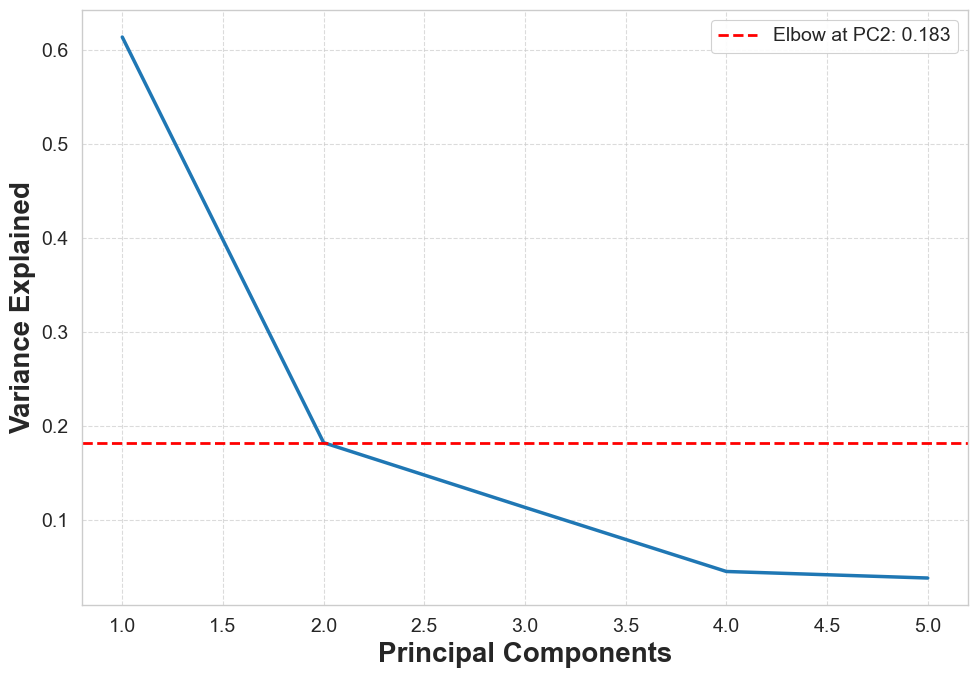

In [222]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Set global font parameters
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 18,  # Increased x and y label font sizes
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})

# Standardize 
scaler = StandardScaler()

# Use copy of data frame
pca_data = pairplot_data.copy()

# Apply log transformation
# Adding a small constant to avoid log(0) issues
log_transformed_data = np.log1p(pca_data)

# Then standardize the log-transformed data
scaled_pca_data = pd.DataFrame(scaler.fit_transform(log_transformed_data), columns=pca_data.columns)

# Fit PCA on the scaled, log-transformed data
pca = PCA(n_components=5)
pca_fit = pca.fit_transform(scaled_pca_data)

# Scree Plot 
PC_values = np.arange(pca.n_components_) + 1  
plt.figure(figsize=(10, 7))  
sns.lineplot(x=PC_values, y=pca.explained_variance_ratio_, linewidth=2.5) 

# Red Dashed line to signify elbow 
plt.axhline(y=pca.explained_variance_ratio_[1], color='red', linestyle='--', 
           linewidth=2, label=f'Elbow at PC2: {pca.explained_variance_ratio_[1]:.3f}')

plt.legend(frameon=True, framealpha=0.9)

plt.xlabel("Principal Components", fontsize=20, fontweight='bold')  
plt.ylabel("Variance Explained", fontsize=20, fontweight='bold')  

plt.grid(True, linestyle='--', alpha=0.7)

plt.tick_params(axis='both', which='major', labelsize=14, width=1.5, length=6)


plt.tight_layout()

print("Variance Explained by Each Principal Component:")
for i in range(1, len(pca.explained_variance_ratio_)+1):
    print(f"Principal Component {i}: {pca.explained_variance_ratio_[i-1]:.4f} ({pca.explained_variance_ratio_[i-1]*100:.2f}%)")

# Create a DataFrame with PC1 and PC2
pca_df = pd.DataFrame({
    'PC1': pca_fit[:, 0],
    'PC2': pca_fit[:, 1]
})

pca_df.index = pairplot_data.index

print("\nFirst few rows of PC scores:")
print(pca_df.head())

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
print(f"\nCumulative variance explained by first two components: {cumulative_variance[1]:.4f} ({cumulative_variance[1]*100:.2f}%)")

plt.savefig('pca_scree_plot.png', dpi=600, bbox_inches='tight')


In [223]:
game_data = pd.concat([combined_games, pca_df], axis=1)
game_data_exploded = game_data.explode('genre')

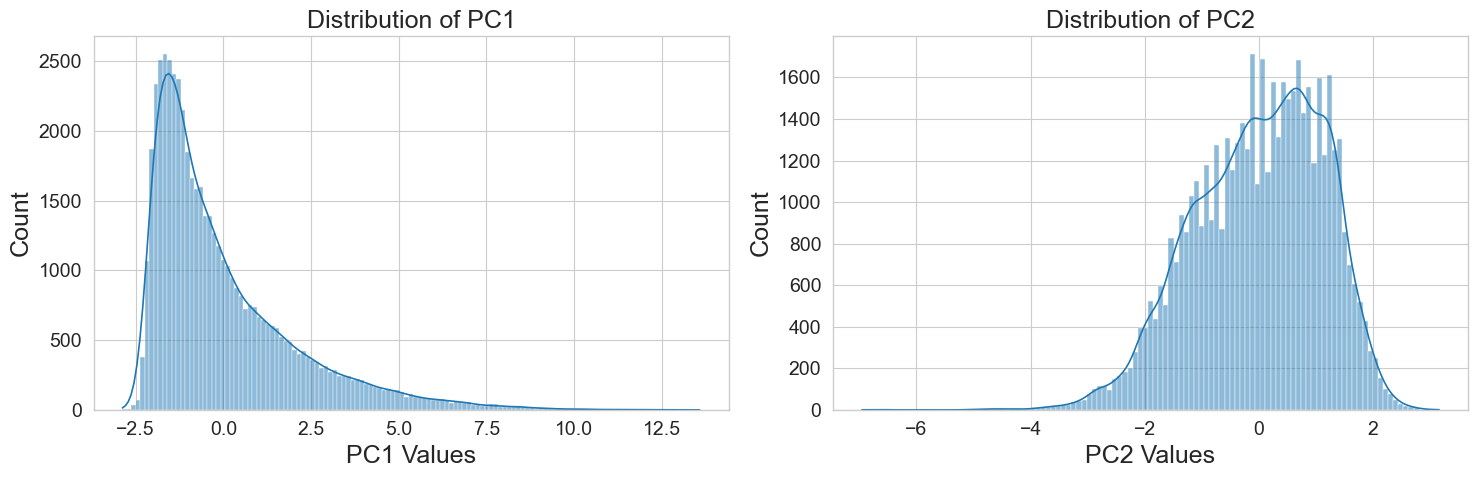

,release_year,positive,review_score,negative,total,concurrent_users_yesterday,owners_average
0,-6.076518,4.254041,1.645633,3.194496,4.252442,6.076834,4.815213
1,-6.388485,2.427673,1.079387,2.241040,2.426476,2.292007,4.297299
2,-5.141552,2.344815,1.079387,1.973555,2.320593,2.607787,4.297299
3,-5.764707,1.871688,1.079387,1.837085,1.877953,0.866836,4.297299
4,-6.388485,3.013221,1.645633,2.249506,2.982354,2.738963,3.727835


In [224]:
# Standardize 
scaler = StandardScaler()

# Use copy of data frame
pca_data = pairplot_data.copy()

# Apply log transformation
# Adding a small constant to avoid log(0) issues
log_transformed_data = np.log1p(pca_data)

# Then standardize the log-transformed data
scaled_pca_data = pd.DataFrame(scaler.fit_transform(log_transformed_data), columns=pca_data.columns)

# Fit PCA on the scaled, transformed data
pca = PCA(n_components=2)
pca_fit = pca.fit_transform(scaled_pca_data)

pca_df = pd.DataFrame(data=pca_fit, columns=['PC1', 'PC2'], index=pairplot_data.index)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# PC1 distribution
sns.histplot(pca_df['PC1'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of PC1')
axes[0].set_xlabel('PC1 Values')

# PC2 distribution
sns.histplot(pca_df['PC2'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of PC2')
axes[1].set_xlabel('PC2 Values')


plt.tight_layout()
plt.show()

scaled_pca_data.head()


### Bootstrapping and PCA Distribution 

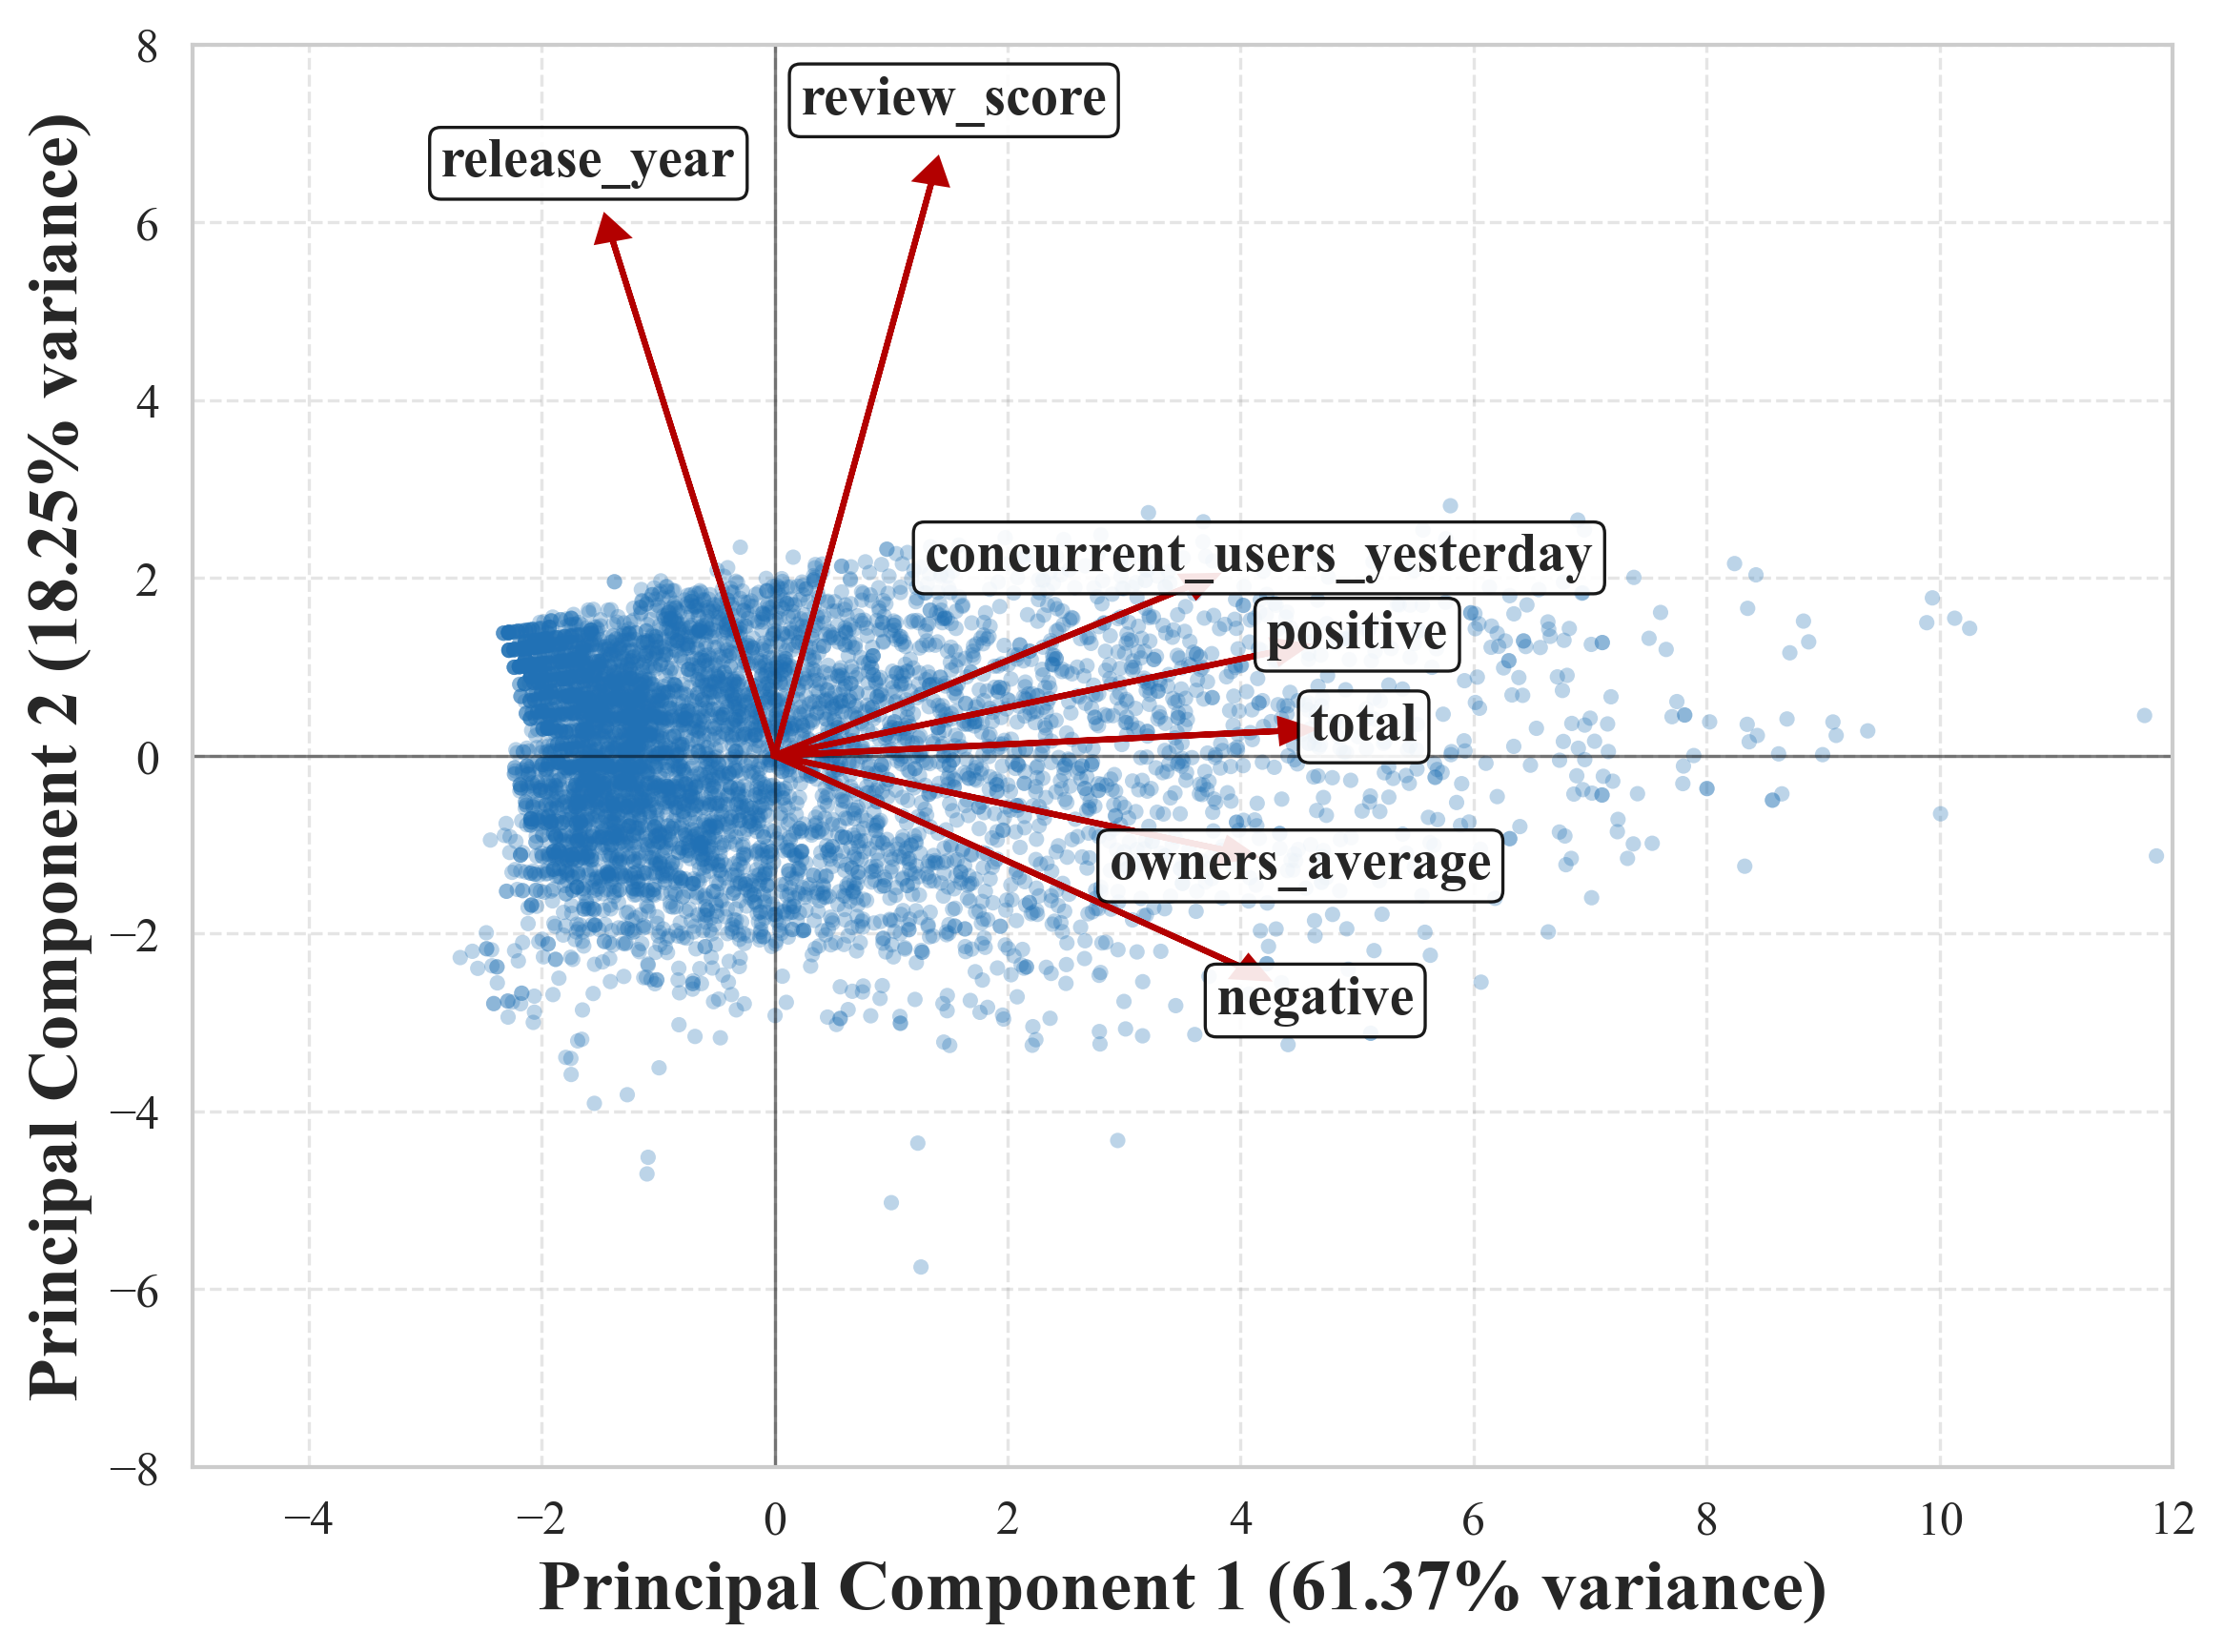

In [225]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['mathtext.fontset'] = 'cm'  

# Increase overall font size
plt.rcParams['font.size'] = 14  
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['figure.titlesize'] = 18

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)  

fig.patch.set_facecolor('white')

blues = ['#2171b5', '#2171b5', '#2171b5'] 

for i in range(3):
    boot_sample = resample(pca_df, n_samples=2000, random_state=i*10)
    ax.scatter(
        boot_sample['PC1'], 
        boot_sample['PC2'],
        color=blues[i],
        alpha=0.3,  
        s=15,       
        label=f'Bootstrap Sample {i+1}',
        edgecolors='none'  
    )

features = pca_data.columns.tolist()

# Get the PCA components 
loadings = pca.components_
n_components = 2

arrow_scale = 6.7
max_arrow_length = np.max(np.abs(loadings[:n_components, :]))

# Plot feature vectors
for i, feature in enumerate(features):
    x = loadings[0, i] * arrow_scale / max_arrow_length
    y = loadings[1, i] * arrow_scale / max_arrow_length
    
    ax.arrow(0, 0, x, y, color='#b30000', linewidth=1.5, head_width=0.25, 
             head_length=0.25, length_includes_head=True, zorder=5)
    
    text_offset = 1.1
    text_x = x * text_offset
    text_y = y * text_offset
    
    ax.text(text_x, text_y, feature, 
            ha='center', va='center', fontsize=14, fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='black', alpha=0.9, boxstyle='round,pad=0.2', linewidth=0.8),
            zorder=6)

ax.grid(True, linestyle='--', alpha=0.2, color='gray')

ax.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=0.8, zorder=1)
ax.axvline(x=0, color='black', linestyle='-', alpha=0.5, linewidth=0.8, zorder=1)

ax.set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} variance)', 
              fontsize=18, fontweight='bold')
ax.set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} variance)', 
              fontsize=18, fontweight='bold')

ax.set_xlim(-5, 12)
ax.set_ylim(-8, 8)
plt.tight_layout()

plt.show()

### The Genre Defining games 

In [226]:
# Combined dataframe of paid games and pca values 

genre_defining = game_data_exploded.sort_values(by='PC1', ascending=False)

action_genre_defining = genre_defining[genre_defining['genre'] == 'Action']                            
adventure_genre_defining = genre_defining[genre_defining['genre'] == 'Adventure']                       
indie_genre_defining = genre_defining[genre_defining['genre'] == 'Indie']                               
casual_genre_defining = genre_defining[genre_defining['genre'] == 'Casual']
rpg_genre_defining = genre_defining[genre_defining['genre'] == 'RPG']
simulation_genre_defining = genre_defining[genre_defining['genre'] == 'Simulation']
multiplayer_genre_defining = genre_defining[genre_defining['genre'] == 'Massively Multiplayer']
strategy_genre_defining = genre_defining[genre_defining['genre'] == 'Strategy']

genre_defining

,app_id,name,release_date,release_year,positive,review_score,review_score_description,negative,total,genre,concurrent_users_yesterday,owners_average,tag,category,PC1,PC2
1061,578080,PUBG: BATTLEGROUNDS,2017-12-21,2017,1440190.0,5,Mixed,1008083.0,2448273.0,Action,642236,75000000.0,"[Action, Battle Royale, Co-op, Competitive, Di...","[Multi-player, Online PvP, PvP, Remote Play on...",13.586919,-0.812392
1061,578080,PUBG: BATTLEGROUNDS,2017-12-21,2017,1440190.0,5,Mixed,1008083.0,2448273.0,Massively Multiplayer,642236,75000000.0,"[Action, Battle Royale, Co-op, Competitive, Di...","[Multi-player, Online PvP, PvP, Remote Play on...",13.586919,-0.812392
1061,578080,PUBG: BATTLEGROUNDS,2017-12-21,2017,1440190.0,5,Mixed,1008083.0,2448273.0,Adventure,642236,75000000.0,"[Action, Battle Royale, Co-op, Competitive, Di...","[Multi-player, Online PvP, PvP, Remote Play on...",13.586919,-0.812392
0,440,Team Fortress 2,2007-10-10,2007,990978.0,8,Very Positive,130730.0,1121708.0,Action,59701,75000000.0,"[Action, Cartoon, Cartoony, Class-Based, Co-op...","[Captions available, Commentary available, Cro...",12.934622,-1.337668
1752,252490,Rust,2018-02-08,2018,972209.0,8,Very Positive,144136.0,1116345.0,Indie,99265,35000000.0,"[Action, Adventure, Building, Co-op, Crafting,...","[Co-op, Cross-Platform Multiplayer, In-App Pur...",12.342268,0.908077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51448,1990830,A Match with a Succubus Witch,2022-06-23,2022,0.0,3,Negative,10.0,10.0,Indie,0,10000.0,"[Action, Anime, Cartoony, Casual, Colorful, Fa...","[Family Sharing, Remote Play Together, Single-...",-2.787445,-2.068464
51448,1990830,A Match with a Succubus Witch,2022-06-23,2022,0.0,3,Negative,10.0,10.0,Simulation,0,10000.0,"[Action, Anime, Cartoony, Casual, Colorful, Fa...","[Family Sharing, Remote Play Together, Single-...",-2.787445,-2.068464
70060,2983840,#!/bin/bash,2024-05-27,2024,0.0,3,Negative,10.0,10.0,Adventure,0,10000.0,"[2D, Adventure, Casual, Clicker, Indie, Point ...","[Family Sharing, Single-player, Steam Achievem...",-2.879450,-1.684900
70060,2983840,#!/bin/bash,2024-05-27,2024,0.0,3,Negative,10.0,10.0,Indie,0,10000.0,"[2D, Adventure, Casual, Clicker, Indie, Point ...","[Family Sharing, Single-player, Steam Achievem...",-2.879450,-1.684900


C:\Users\Georg\AppData\Local\Temp\ipykernel_14856\1241423759.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Georg\AppData\Local\Temp\ipykernel_14856\1241423759.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), ha='right')
C:\Users\Georg\AppData\Local\Temp\ipykernel_14856\1241423759.py:66: UserWarning: tight_layout not applied: number of rows in subplot specifications must be multiples of one another.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


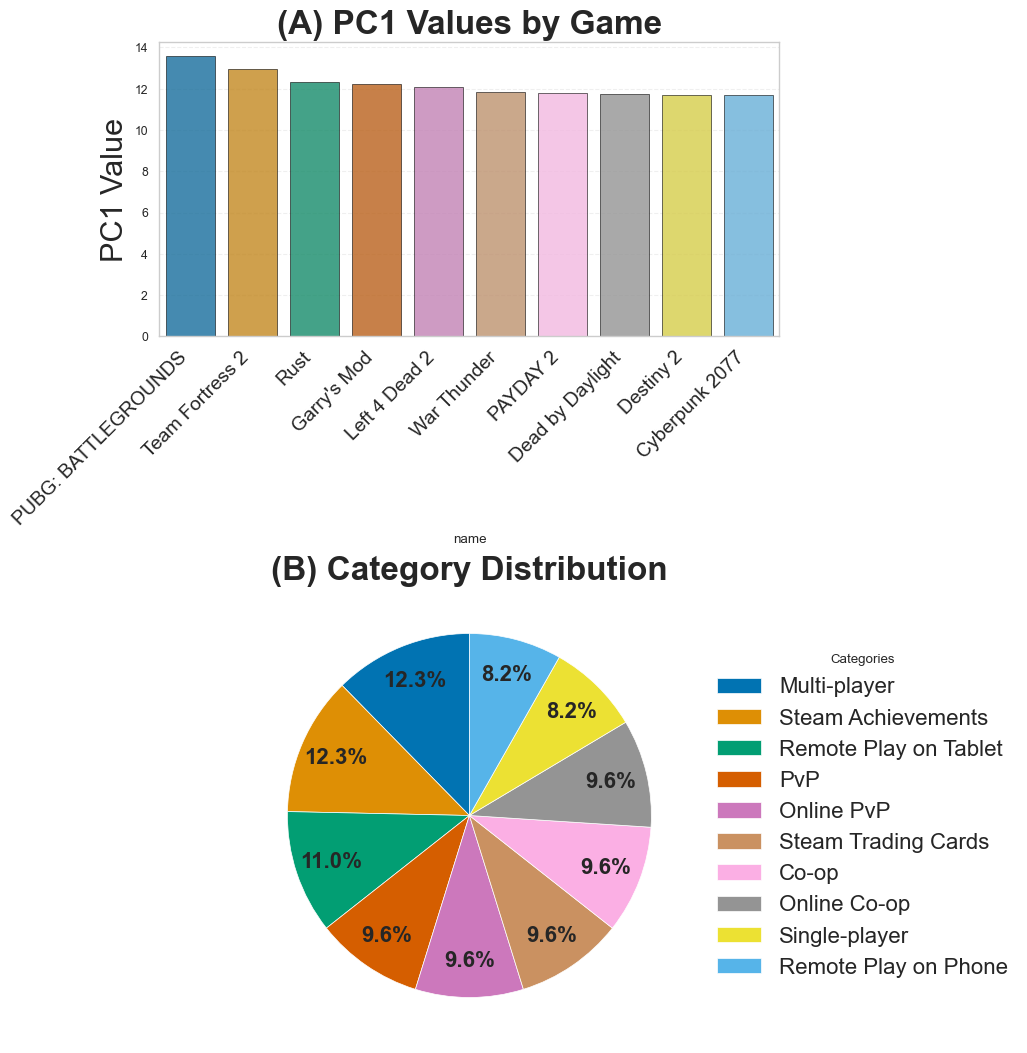

In [227]:
game_data = game_data.sort_values(by='PC1', ascending=False)
top_10 = game_data.head(10)
top_categories = top_10.explode(column='category')


plt.rcParams.update({
    'font.family': 'serif', 
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'axes.labelsize': 26,
    'axes.titlesize': 24,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20
})
sns.set_style("whitegrid")
sns.set_context("paper")

categories_counts = top_categories['category'].value_counts().nlargest(10)

fig = plt.figure(figsize=(8, 13)) 

bar_palette = sns.color_palette("colorblind", len(top_10))
category_palette = sns.color_palette("colorblind", len(categories_counts))

subplot_labels = ['A', 'B']

# 1. Bar Chart - Top 10 Games 
ax1 = plt.subplot(3, 1, 1)
sns.barplot(
    x='name', 
    y='PC1', 
    data=top_10, 
    palette=bar_palette, 
    edgecolor='black', 
    linewidth=0.5, 
    alpha=0.8, 
    ax=ax1
)
ax1.set_title(f'({subplot_labels[0]}) PC1 Values by Game', fontweight='bold', fontsize=24)
ax1.set_ylabel('PC1 Value', fontsize=22)
ax1.tick_params(axis='x', rotation=45, labelsize=14)
ax1.set_xticklabels(ax1.get_xticklabels(), ha='right')
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# 2. Pie Chart - Categories
ax2 = plt.subplot(2, 1, 2)
wedges, texts, autotexts = ax2.pie(
    categories_counts, 
    labels=None, 
    autopct='%1.1f%%', 
    pctdistance=0.8, 
    colors=category_palette, 
    startangle=90, 
    wedgeprops={'edgecolor': 'white', 'linewidth': 0.5}
)
plt.setp(autotexts, size=16, weight='bold')
ax2.legend(
    wedges, 
    categories_counts.index, 
    title="Categories", 
    loc="center left", 
    bbox_to_anchor=(1, 0, 0.5, 1), 
    fontsize=16
)
ax2.set_title(f'({subplot_labels[1]}) Category Distribution', fontweight='bold', fontsize=24)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

C:\Users\Georg\AppData\Local\Temp\ipykernel_14856\3630406019.py:61: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


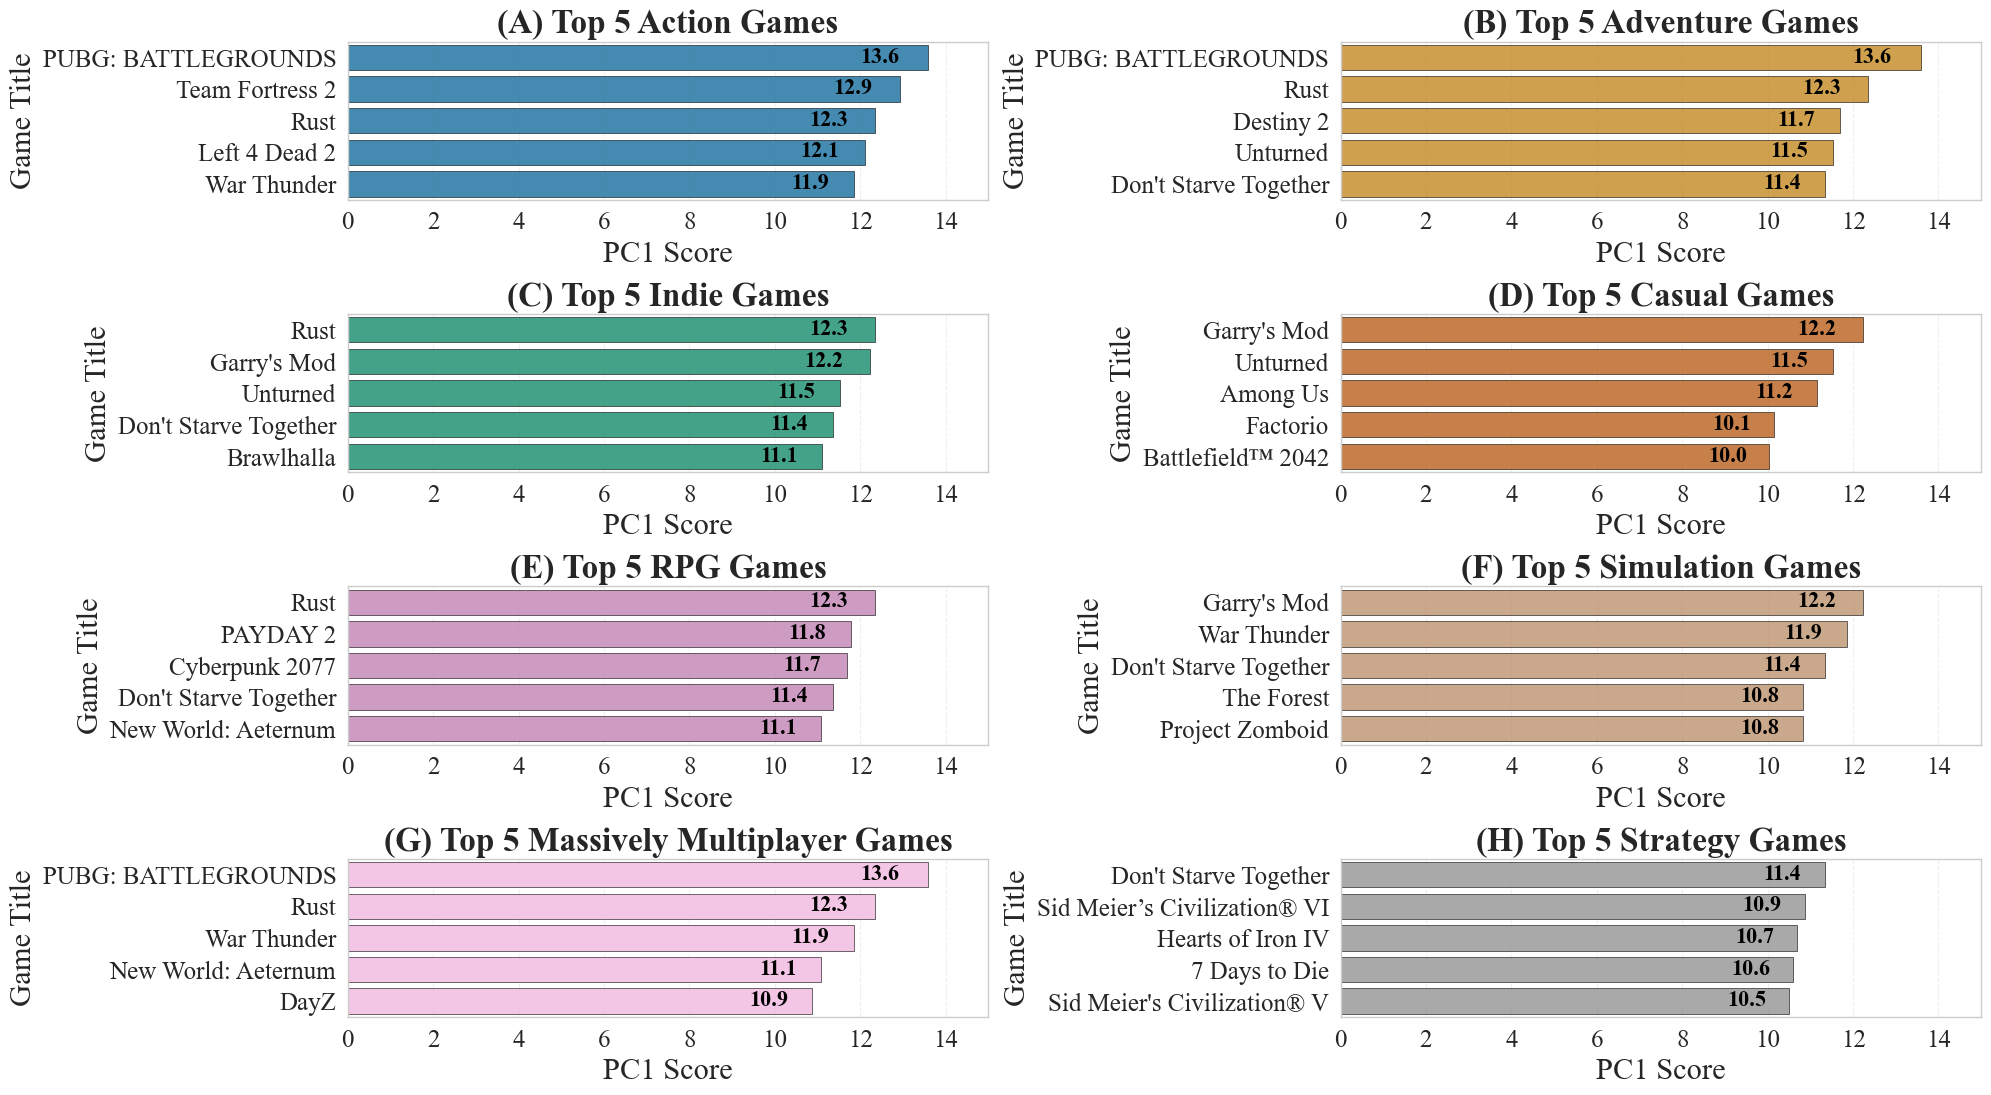

In [228]:
genres = {
    'Action': action_genre_defining,
    'Adventure': adventure_genre_defining,
    'Indie': indie_genre_defining,
    'Casual': casual_genre_defining,
    'RPG': rpg_genre_defining,
    'Simulation': simulation_genre_defining,
    'Massively Multiplayer': multiplayer_genre_defining,
    'Strategy': strategy_genre_defining
}

color_palette = sns.color_palette("colorblind", 8)

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'axes.labelsize': 22,  
    'axes.titlesize': 24,  
    'xtick.labelsize': 18,  
    'ytick.labelsize': 18,  
    'legend.fontsize': 16,  
})

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 12), constrained_layout=True)
axes = axes.flatten()

subplot_labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

# Plot each genre
for i, (genre_name, genre_df) in enumerate(genres.items()):
    # Get top 5 games by PC1 score
    top_5 = genre_df.sort_values('PC1', ascending=False).head(5)
    
    ax = axes[i]
    bars = sns.barplot(
        x='PC1',
        y='name',
        data=top_5,
        color=color_palette[i],
        edgecolor='black',
        linewidth=0.5,
        alpha=0.8,
        ax=ax
    )
    
    ax.set_title(f'({subplot_labels[i]}) Top 5 {genre_name} Games', fontweight='bold', fontsize=24)
    ax.set_xlabel('PC1 Score', fontsize=22)
    ax.set_ylabel('Game Title', fontsize=22)
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    ax.tick_params(axis='y', labelsize=18)
    ax.set_xlim(0, 15)

    for bar in ax.patches:
        width = bar.get_width()
        ax.text(width * 0.95, 
                bar.get_y() + bar.get_height()/2, 
                f'{width:.1f}', 
                ha='right', va='center',
                color='black', fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

Original dataframe shape: (144707, 16)
Sampled dataframe shape: (2000, 16)


c:\Users\Georg\anaconda3\envs\FDSCW2\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


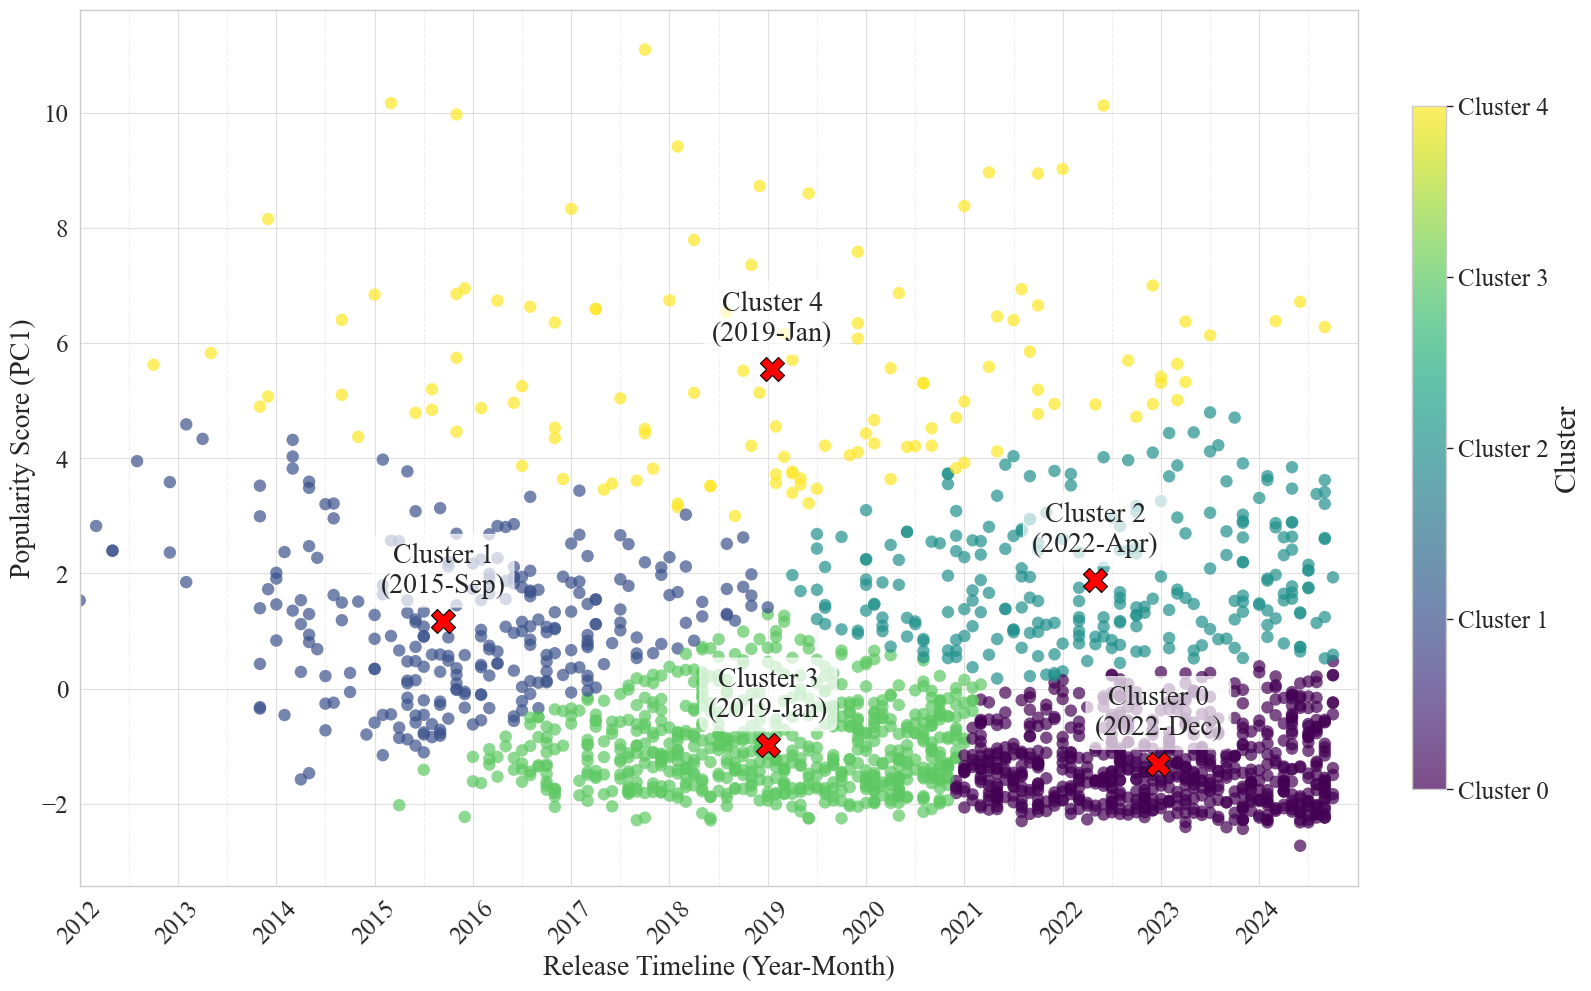

In [229]:
sampled_df = genre_defining.sample(n=2000, random_state=42)
print(f"Original dataframe shape: {genre_defining.shape}")
print(f"Sampled dataframe shape: {sampled_df.shape}")

# get the exact month in the year 
if 'release_date' in sampled_df.columns:
    sampled_df['release_date'] = pd.to_datetime(sampled_df['release_date'], errors='coerce')
    sampled_df['year_month_float'] = sampled_df['release_date'].dt.year + (sampled_df['release_date'].dt.month - 1) / 12
elif 'release_month' in sampled_df.columns and 'release_year' in sampled_df.columns:

    sampled_df['year_month_float'] = sampled_df['release_year'] + (sampled_df['release_month'] - 1) / 12
else:
    sampled_df['release_month'] = np.random.randint(1, 13, size=len(sampled_df))
    sampled_df['year_month_float'] = sampled_df['release_year'] + (sampled_df['release_month'] - 1) / 12

# 1. Perform clustering 
features = ['PC1', 'year_month_float']
X = sampled_df[features].copy()

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-means clustering
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
sampled_df['cluster'] = kmeans.fit_predict(X_scaled)

centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features
)
centers['cluster'] = range(n_clusters)

plt.figure(figsize=(16, 10))  

scatter = plt.scatter(
    sampled_df['year_month_float'], 
    sampled_df['PC1'],
    c=sampled_df['cluster'], 
    cmap='viridis', 
    alpha=0.7,
    s=80,  
    edgecolor='none'
)

for i, center in centers.iterrows():
    plt.scatter(
        center['year_month_float'], 
        center['PC1'], 
        c='red', 
        s=300, 
        marker='X', 
        edgecolors='black',
        zorder=5
    )
    
    year = int(center['year_month_float'])
    month = int((center['year_month_float'] - year) * 12) + 1
    month_name = datetime(2000, month, 1).strftime('%b')
    
    plt.text(
        center['year_month_float'], 
        center['PC1'] + 0.5, 
        f'Cluster {int(center["cluster"])}\n({year}-{month_name})', 
        fontsize=20, 
        ha='center',
        bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.3')
    )

years = range(2012, 2025)
plt.xlim(2012, 2025)
plt.xticks(
    ticks=years, 
    labels=[str(y) for y in years], 
    rotation=45, 
    fontsize=18 
)

minor_ticks = np.array([y + 0.5 for y in years])
plt.gca().set_xticks(minor_ticks, minor=True)
plt.gca().tick_params(which='minor', length=6, color='gray', width=1.5)

plt.grid(True, which='major', alpha=0.6, linestyle='-')
plt.grid(True, which='minor', alpha=0.3, linestyle='--')

plt.xlabel('Release Timeline (Year-Month)', fontsize=20)
plt.ylabel('Popularity Score (PC1)', fontsize=20)

cbar = plt.colorbar(scatter, label='Cluster', fraction=0.025, pad=0.04)
cbar.ax.tick_params(labelsize=18)
cbar.set_ticks(range(n_clusters))
cbar.set_ticklabels([f'Cluster {i}' for i in range(n_clusters)])

plt.tight_layout()
plt.show()

### Projecting PC1 and PC2 to each game 

,release_year,positive,review_score,negative,total,concurrent_users_yesterday,owners_average,PC1,PC2
1061,2017,1440190.0,5,1008083.0,2448273.0,642236,75000000.0,13.586919,-0.812392
1061,2017,1440190.0,5,1008083.0,2448273.0,642236,75000000.0,13.586919,-0.812392
1061,2017,1440190.0,5,1008083.0,2448273.0,642236,75000000.0,13.586919,-0.812392
0,2007,990978.0,8,130730.0,1121708.0,59701,75000000.0,12.934622,-1.337668
1752,2018,972209.0,8,144136.0,1116345.0,99265,35000000.0,12.342268,0.908077


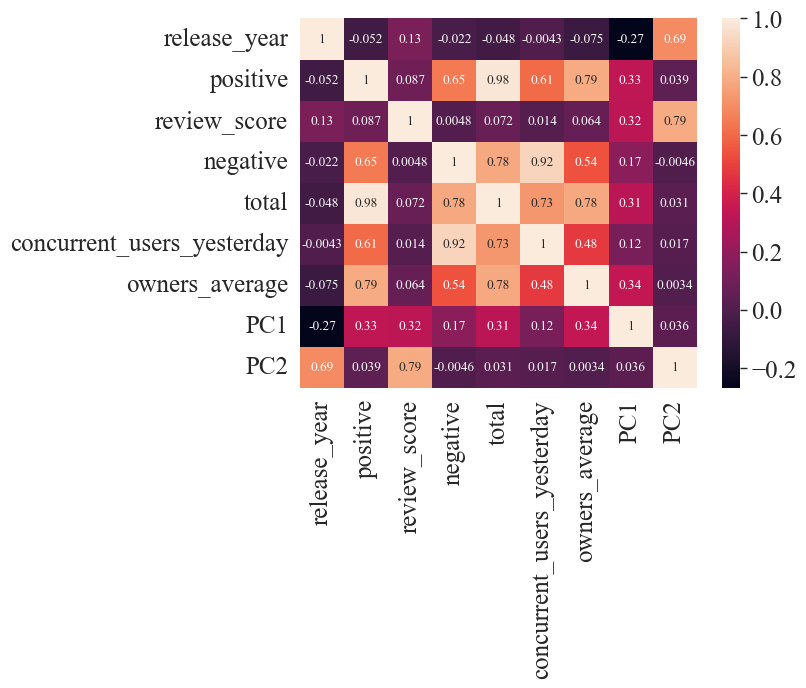

In [230]:
heat_map = genre_defining[['release_year', 'positive', 'review_score', 'negative', 'total', 'concurrent_users_yesterday', 'owners_average', 'PC1', 'PC2']]
sns.heatmap(heat_map.corr(), annot=True)

heat_map.head()

In [231]:
# Sort by PC1 value in descending order (highest PC1 first)
sorted_games = genre_defining.copy()



In [232]:

exploded_sorted_games = temporal_analysis.explode('genre')


action_games = exploded_sorted_games[exploded_sorted_games['genre'] == 'Action']
Adventure_games = exploded_sorted_games[exploded_sorted_games['genre'] == 'Adventure']
Indie_games = exploded_sorted_games[exploded_sorted_games['genre'] == 'Indie']
Massively_Multiplayer_games = exploded_sorted_games[exploded_sorted_games['genre'] == 'Massively Multiplayer']
RPG_games = exploded_sorted_games[exploded_sorted_games['genre'] == 'RPG']
Simulation_games = exploded_sorted_games[exploded_sorted_games['genre'] == 'Simulation']
Strategy_games = exploded_sorted_games[exploded_sorted_games['genre'] == 'Strategy']



### Handling Games with multiple Genres 

# Temporal Analysis 

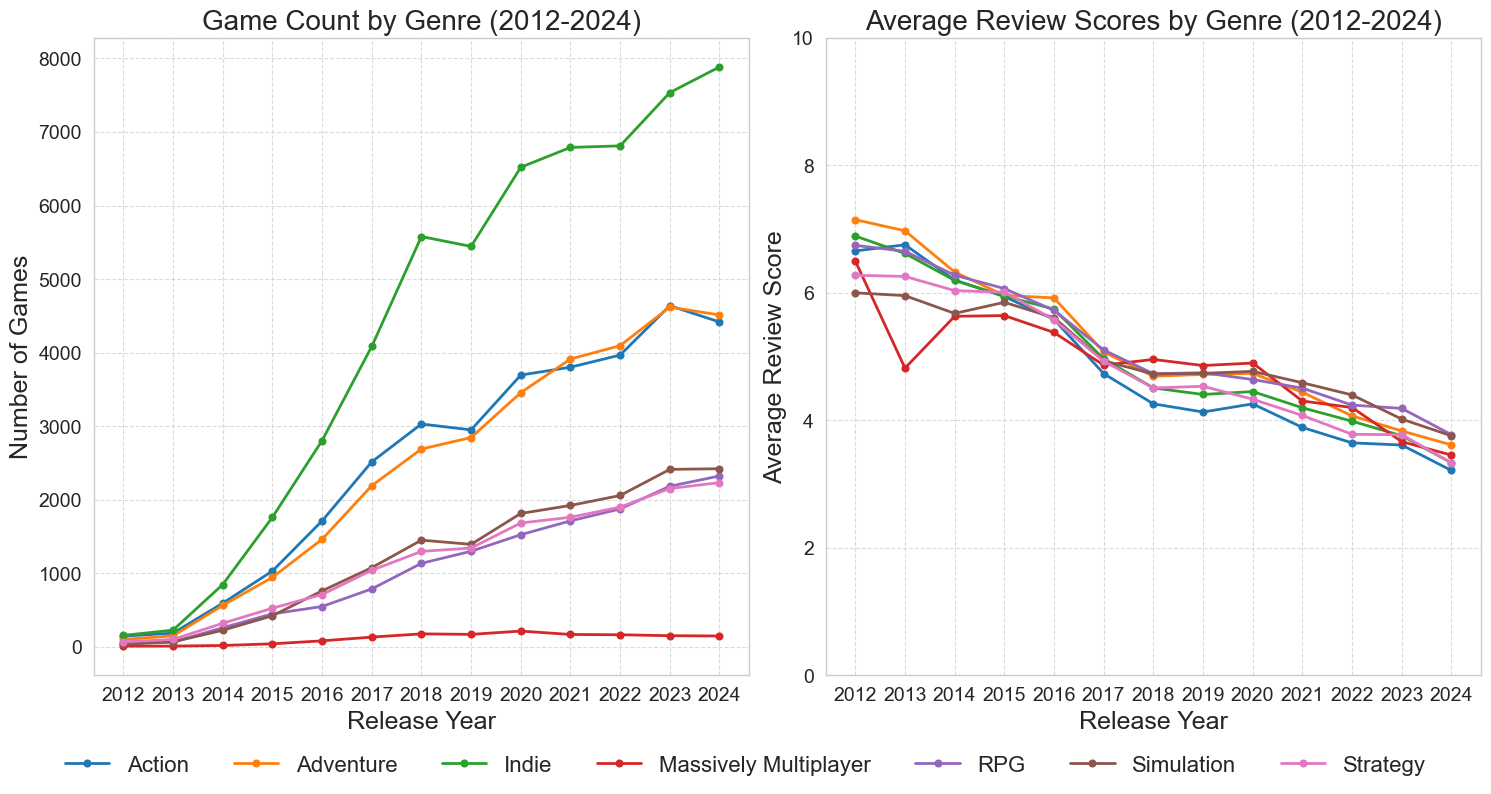

In [233]:
sns.set_style("whitegrid")

filtered_games = exploded_sorted_games[(exploded_sorted_games['release_year'] >= 2012) & 
                                       (exploded_sorted_games['release_year'] <= 2024)]

genres_to_include = ['Action', 'Adventure', 'Indie', 'Massively Multiplayer', 'RPG', 'Simulation', 'Strategy']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))

# Count games by genre and year
genre_year_counts = filtered_games.groupby(['release_year', 'genre']).size().reset_index(name='count')

# Filter for specified genres
genre_filtered_counts = genre_year_counts[genre_year_counts['genre'].isin(genres_to_include)]

for genre in genres_to_include:
    genre_data = genre_filtered_counts[genre_filtered_counts['genre'] == genre]
    if not genre_data.empty:
        ax1.plot(genre_data['release_year'], genre_data['count'], marker='o', linewidth=2, label=genre)

ax1.set_title('Game Count by Genre (2012-2024)', fontsize=20)
ax1.set_xlabel('Release Year', fontsize=18)
ax1.set_ylabel('Number of Games', fontsize=18)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_xticks(range(2012, 2025))
ax1.tick_params(axis='both', which='major', labelsize=14)  

# Calculate average review scores by genre and year
avg_scores = filtered_games.groupby(['release_year', 'genre'])['review_score'].mean().reset_index(name='avg_score')

filtered_scores = avg_scores[avg_scores['genre'].isin(genres_to_include)]

for genre in genres_to_include:
    genre_data = filtered_scores[filtered_scores['genre'] == genre]
    if not genre_data.empty:
        ax2.plot(genre_data['release_year'], genre_data['avg_score'], marker='o', linewidth=2, label=genre)

ax2.set_title('Average Review Scores by Genre (2012-2024)', fontsize=20)
ax2.set_xlabel('Release Year', fontsize=18)
ax2.set_ylabel('Average Review Score', fontsize=18)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.set_ylim(0, 10)  
ax2.set_xticks(range(2012, 2025))
ax2.tick_params(axis='both', which='major', labelsize=14) 


handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(genres_to_include), fontsize=16, bbox_to_anchor=(0.5, 0))

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  

plt.savefig('game_trends_2012_to_2024.png', dpi=300, bbox_inches='tight')
plt.show()